<a href="https://colab.research.google.com/github/ayyash-ayyub/Android-Handle-Audio-Example/blob/master/modelSVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ds_heart.csv to ds_heart.csv


In [ ]:
import pandas as pd

df = pd.read_csv('/content/ds_heart.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
X = df.drop(columns=['target'])
Y = df['target']

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=0)

In [ ]:
from sklearn.svm import SVC

model_svc = SVC(
    kernel='rbf',
    C=2,
    probability=True
)

model_svc.fit(X_train, y_train)

SVC(C=2, probability=True)

In [ ]:
import joblib

joblib.dump(model_svc, "svc.pkl")

['svc.pkl']

In [ ]:
# Prediksi menggunakan model yang dilatih
y_pred_svc = model_svc.predict(X_test)

# Menghitung confusion matrix untuk mengevaluasi kinerja model
svc_conf_matrix = confusion_matrix(y_test, y_pred_svc)

# Menghitung akurasi model
svc_acc_score = accuracy_score(y_test, y_pred_svc)

# Menampilkan confusion matrix
print("Confusion Matrix:")
print(svc_conf_matrix)
print("\n")

# Menampilkan akurasi model
print("Nilai Akurasi untuk model Support Vector Classifier:", svc_acc_score * 100, '%\n')

# Menampilkan laporan klasifikasi
print("Classification Report:")
print(classification_report(y_test, y_pred_svc))

Confusion Matrix:
[[22  5]
 [ 2 32]]


Nilai Akurasi untuk model Support Vector Classifier: 88.52459016393442 %

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.81      0.86        27
           1       0.86      0.94      0.90        34

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.88        61



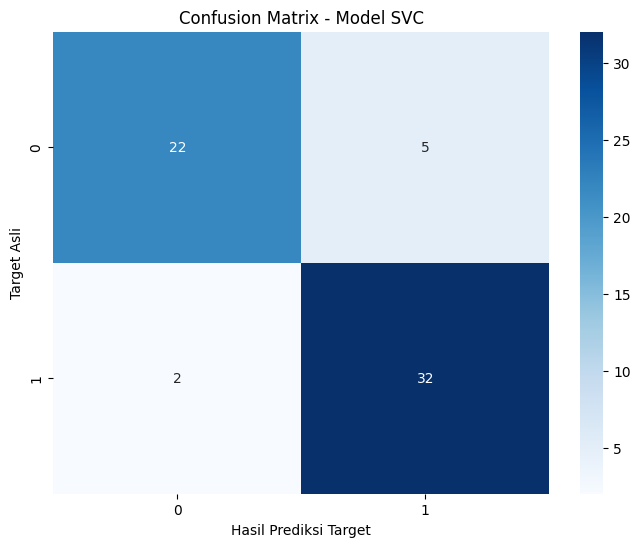

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt



# Heatmap dengan persentase
plt.figure(figsize=(8, 6))
sns.heatmap(svc_conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title("Confusion Matrix - Model SVC")
plt.xlabel("Hasil Prediksi Target")
plt.ylabel("Target Asli")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

joblib.dump(model_svc, 'model_svc.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']